Import de paquets

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, SubsetRandomSampler, ConcatDataset, Dataset,ChainDataset
from torchvision import datasets, transforms, models
from torchvision.transforms import v2
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import my_helper
import logging
import multiprocessing
from tqdm import tqdm
from copy import deepcopy
import shutil
from glob import glob

In [2]:
logger = logging.getLogger("mlflow")
logger.setLevel(logging.DEBUG)

seed pour la reproductibilité   

In [3]:
def set_seed(seed=42):
    
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

vérification et choix du GPU si disponible

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du périphérique : {device}")

Utilisation du périphérique : cuda


In [5]:
# 1. Définition des chemins (ajustez-les si nécessaire)
source_dir = os.getcwd()+"\\data\\Cat_Dog_data"
target_dir = os.getcwd()+ "\\data\\Cat_Dog_ordered"

os.makedirs(target_dir, exist_ok=True)

# 2. Création de la nouvelle structure de dossier
for label in ["cat", "dog"]:
    os.makedirs(os.path.join(target_dir, label), exist_ok=True)

print("Début du déplacement des images...")

# 3. Recherche et déplacement des images
# Le pattern '*' englobe 'train' et 'test', et le deuxième '*' englobe les extensions (jpg, png, etc.)
search_pattern = os.path.join(source_dir, "*", "*", "*")
files = glob(search_pattern)

moved_count = 0

for file_path in files:
    # On vérifie qu'il s'agit bien d'un fichier et non d'un dossier
    if os.path.isfile(file_path):
        # On extrait les composants du chemin
        # Exemple : 'Cat_Dog_data/train/cat/img_1.jpg' -> ['Cat_Dog_data', 'train', 'cat', 'img_1.jpg']
        path_parts = file_path.split(os.sep)
        
        # Le label ('cat' ou 'dog') est l'avant-dernier élément
        label = path_parts[-2] 
        filename = path_parts[-1]
        
        if label in ["cat", "dog"]:
            # Pour éviter que des images de 'train' et 'test' ayant le même nom se détruisent,
            # on ajoute un préfixe (ex: 'train_img_1.jpg')
            subfolder = path_parts[-3] # 'train' ou 'test'
            new_filename = f"{subfolder}_{filename}"
            
            # Chemin de destination
            destination = os.path.join(target_dir, label, new_filename)
            
            # Déplacement du fichier
            shutil.move(file_path, destination)
            moved_count += 1

print(f"Terminé ! {moved_count} images ont été déplacées avec succès dans '{target_dir}'.")

Début du déplacement des images...
Terminé ! 0 images ont été déplacées avec succès dans 'c:\Users\dodzi\Documents\Codes Python\cnn-catsdogs-AHNERTDodzi\data\Cat_Dog_ordered'.


In [6]:
config = {
    "data_dir": "data/Cat_Dog_ordered",
    "batch_size": 64,
    "num_workers": 4,
    "train_size": 0.8,
    "val_size": 0.1,
    "test_size": 0.1,
    "epochs": 20,
}

Préparation des focntion de transformation et augmentation de données avec redimensionnement, 50% aléatoire de rotation de 15%, rotation horizontale de l'image, ainsi que normalisation de l'image pour train et redimensionnement et normalisation des données de test et validation.

In [7]:
train_transforms = v2.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])
test_val_transforms = v2.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])



In [8]:

def get_data_loaders(data_dir, batch_size, train_size, valid_size, num_workers, train_transforms, test_val_transforms):
    train_dataset = datasets.ImageFolder(root=data_dir, transform=train_transforms)
    test_val_dataset = datasets.ImageFolder(root=data_dir, transform=test_val_transforms)
    
    n_tot = len(train_dataset)
    
    # 2. Calculer la taille des segments (80% / 10% / 10%)
    split_train = int(np.floor(train_size * n_tot))
    split_val = int(np.floor((train_size + valid_size) * n_tot))
    
    # 3. Mélanger et séparer les indices de manière aléatoire
    shuffled_indices = torch.randperm(n_tot).tolist()
    
    train_idx = shuffled_indices[:split_train]
    valid_idx = shuffled_indices[split_train:split_val]
    test_idx = shuffled_indices[split_val:]
    
    # 4. Définir les samplers basés sur les indices
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)
    test_sampler = SubsetRandomSampler(test_idx)
    
    # 5. Créer les DataLoaders
    # Note : On applique le train_dataset uniquement au train_loader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers, persistent_workers=True, pin_memory=True)
    valid_loader = DataLoader(test_val_dataset, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers, persistent_workers=True, pin_memory=True)
    test_loader = DataLoader(test_val_dataset, batch_size=batch_size, sampler=test_sampler, num_workers=num_workers, persistent_workers=True, pin_memory=True)
    
    return train_loader, valid_loader, test_loader

# --- Instanciation des DataLoaders ---
train_dl, valid_dl, test_dl = get_data_loaders(
    data_dir=config["data_dir"],
    batch_size=config["batch_size"],
    train_size=config["train_size"],
    valid_size=config["val_size"],
    num_workers=config["num_workers"],
    train_transforms=train_transforms,
    test_val_transforms=test_val_transforms
)

# Regroupement dans le dictionnaire final
data_loaders = {
    'train': train_dl,
    'val': valid_dl,
    'test': test_dl
}

In [9]:
classes = train_dl.dataset.classes
print(f"Classes : {classes}")   

Classes : ['cat', 'dog']


Nombre de batchs pour train, val et test

In [10]:
print(len(data_loaders['train']), len(data_loaders['val']), len(data_loaders['test']))

313 40 40


Test des loaders

In [ ]:
images, labels = next(iter(data_loaders["train"]))
fig, subs = plt.subplots(2, 10, figsize=(25, 4))
print(labels)
for i, sub in enumerate(subs.flatten()):
    my_helper.imshow(images[i], sub)
    sub.set_title([classes[labels[i]]])

In [ ]:
image, label = next(iter(data_loaders["val"]))
my_helper.imshow(image[0],title=f"Label: {label[0]}")

In [ ]:

image, label = next(iter(data_loaders["test"]))
my_helper.imshow(image[0],title=f"Label: {label[0]}")

Conception du modèle

In [11]:
class CNNScratch(nn.Module):
    def __init__(self):
        super(CNNScratch, self).__init__()
        
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 32 * 32, 512),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(512, 2) # Classification binaire (Chats vs Chiens)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [12]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=config["num_workers"], save_path="best_model.pt"):
    best_val_loss = float('inf')
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in tqdm(data_loaders["train"], desc="Train", ncols=100):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        epoch_train_loss = running_loss / len(data_loaders["train"].dataset)
        epoch_train_acc = correct / total
        
        # Phase de Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in tqdm(data_loaders["val"], desc="Validation", ncols=100):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
                
        epoch_val_loss = val_loss / len(data_loaders["val"].dataset)
        epoch_val_acc = val_correct / val_total
        
        if scheduler:
            scheduler.step()
            
        # Sauvegarde du meilleur modèle localement
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), save_path)
            
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
        print(f"Époque {epoch+1}/{num_epochs} -> Train Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f} || Val Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f}")
        
    return history

def evaluate_final_metrics(model, path, loader):
    """Charge le meilleur modèle sauvegardé et calcule les métriques finales."""
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    precision = precision_score(all_labels, all_preds, average='binary')
    recall = recall_score(all_labels, all_preds, average='binary')
    
    return acc, precision, recall, all_labels, all_preds


In [13]:
criterion = nn.CrossEntropyLoss()
epochs = 10
if __name__ == "__main__":
    
# -- Expérience A : From Scratch --
    print("\n--- Lancement Expérience A : CNN From Scratch ---")
    scratch_model = CNNScratch().to(device)
    # Test de l'optimiseur Adam avec un Learning Rate Scheduler (Bonus)
    optimizer_scratch = optim.Adam(scratch_model.parameters(), lr=0.001)
    scheduler_scratch = optim.lr_scheduler.StepLR(optimizer_scratch, step_size=5, gamma=0.1)

history_scratch = train_model(scratch_model, criterion, optimizer_scratch, scheduler_scratch, epochs, "best_scratch.pth")


--- Lancement Expérience A : CNN From Scratch ---


Validation: 100%|███████████████████████████████████████████████████| 40/40 [00:18<00:00,  2.21it/s]


Époque 1/10 -> Train Loss: 2.0118 | Acc: 0.5803 || Val Loss: 0.0632 | Acc: 0.6296


Validation: 100%|███████████████████████████████████████████████████| 40/40 [00:07<00:00,  5.48it/s]


Époque 2/10 -> Train Loss: 0.5128 | Acc: 0.6148 || Val Loss: 0.0606 | Acc: 0.6408


...

Époque 8/10 -> Train Loss: 0.4190 | Acc: 0.7391 || Val Loss: 0.0485 | Acc: 0.7564


Validation: 100%|███████████████████████████████████████████████████| 40/40 [00:07<00:00,  5.19it/s]


Époque 9/10 -> Train Loss: 0.4141 | Acc: 0.7446 || Val Loss: 0.0471 | Acc: 0.7628


Validation: 100%|███████████████████████████████████████████████████| 40/40 [00:07<00:00,  5.04it/s]


Époque 10/10 -> Train Loss: 0.4037 | Acc: 0.7516 || Val Loss: 0.0462 | Acc: 0.7720


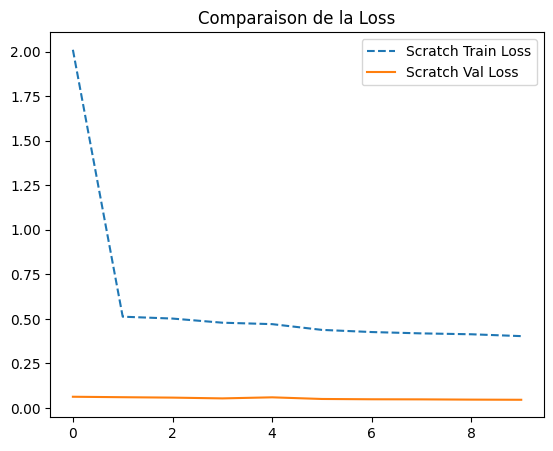

In [14]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_scratch['train_loss'], label='Scratch Train Loss', linestyle='--')
plt.plot(history_scratch['val_loss'], label='Scratch Val Loss')
plt.title('Comparaison de la Loss')
plt.legend()

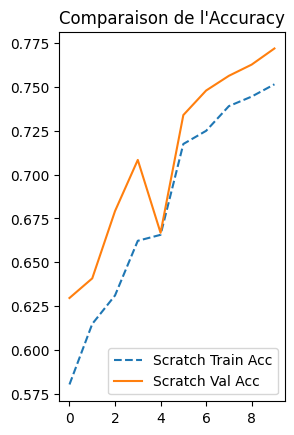

In [15]:
plt.subplot(1, 2, 2)
plt.plot(history_scratch['train_acc'], label='Scratch Train Acc', linestyle='--')
plt.plot(history_scratch['val_acc'], label='Scratch Val Acc')
plt.title("Comparaison de l'Accuracy")
plt.legend()
plt.show()
